L'obiettivo del progetto è stato quello di analizzare la relazione tra il numero di installazioni e il numero di recensioni delle applicazioni disponibili su Google Play Store. Utilizzando un dataset contenente informazioni su diverse app,abbiamo cercato di identificare eventuali anomalie. In particolare, ci siamo concentrati su come un'alta quantità di installazioni potrebbe o meno essere correlata con un numero elevato di recensioni.

In [101]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
from scipy.stats import boxcox, zscore
from scipy.special import inv_boxcox

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression


Il dataset utilizzato è stato il "Google Play Store Apps Dataset", che contiene informazioni su migliaia di applicazioni disponibili su Google Play fino al 2018.

In [301]:
app = pd.read_csv('googleplaystore.csv')
app.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Visualizziamo tutte le categorie presenti nel dataset e raggruppiamole in sette gruppi.

In [303]:
print(app['Category'].unique())
# Mappatura delle categorie originali nelle nuove categorie aggregate
category_map = {
    'ART_AND_DESIGN': 'Entertainment', 'AUTO_AND_VEHICLES': 'Other', 'BEAUTY': 'Shopping', 
    'BOOKS_AND_REFERENCE': 'BusinessAndEducation', 'BUSINESS': 'BusinessAndEducation', 'COMICS': 'Entertainment',
    'COMMUNICATION': 'Social', 'DATING': 'Social', 'EDUCATION': 'BusinessAndEducation', 
    'ENTERTAINMENT': 'Entertainment', 'EVENTS': 'Entertainment', 'FINANCE': 'BusinessAndEducation', 
    'FOOD_AND_DRINK': 'Shopping', 'HEALTH_AND_FITNESS': 'Other', 'HOUSE_AND_HOME': 'Other', 
    'LIBRARIES_AND_DEMO': 'BusinessAndEducation', 'LIFESTYLE': 'BusinessAndEducation', 'GAME': 'Game', 'FAMILY': 'BusinessAndEducation',
    'MEDICAL': 'Other', 'SOCIAL': 'Social', 'SHOPPING': 'Shopping', 'PHOTOGRAPHY': 'Other', 
    'SPORTS': 'Entertainment', 'TRAVEL_AND_LOCAL': 'Other', 'TOOLS': 'Other', 
    'PERSONALIZATION': 'Other', 'PRODUCTIVITY': 'BusinessAndEducation', 'PARENTING': 'Other', 
    'WEATHER': 'Other', 'VIDEO_PLAYERS': 'Other', 'NEWS_AND_MAGAZINES': 'BusinessAndEducation', 
    'MAPS_AND_NAVIGATION': 'Other', '1.9': 'Other'  # Categoria extra
}

app['Category'] = app['Category'].map(category_map).fillna('Other')

['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']


Visualizziamo varie informazioni del dataset tra cui i tipi di dati, gli eventuali duplicati e valori nulli e procediamo alla rimozione di quest'ultimi.

In [ ]:
app.info()
app.isnull().sum()
print(app.duplicated().sum())
app.drop_duplicates()
app.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


Continuiamo con la pulizia dei dati convertendo il peso di tutte le app in Megabyte, eliminiamo eventuali caratteri che non possono essere convertiti in numeri da tutti i dati, facciamo l'encoding di variabili categoriche e convertiamo le stringhe che rappesentano delle date estraendone l'anno.

In [ ]:
def convert_to_mb(size_str):
    if 'M' in size_str:
        return float(size_str.replace('M', ''))
    elif 'k' in size_str:
        return float(size_str.replace('k', '')) * 0.001
    else:
        return None

app['Size'] = app['Size'].apply(convert_to_mb)
app['Size'] = app['Size'].replace('Varies with device', -1)

app['Installs'] = app['Installs'].str.replace('+', '')
app['Installs'] = app['Installs'].str.replace(',', '')
app['Installs'] = pd.to_numeric(app['Installs'], errors='coerce').astype('Int64')

app['Reviews'] = pd.to_numeric(app['Reviews'], errors='coerce').astype('Int64')

app['Rating'] = pd.to_numeric(app['Rating'], errors = 'coerce')

app['Type_Encoded'] = app['Type'].map({'Free': 0, 'Paid': 1})

app['Price'] = app['Price'].str.replace('$', '')
app['Price'] = pd.to_numeric(app['Price'], errors='coerce')

content_rating_map = {
    'Everyone': 0,
    'Everyone 10+': 1,
    'Teen': 2,
    'Mature 17+': 3,
    'Adults only 18+': 4,
    'Unrated': -1
}

app['Content Rating Encoded'] = app['Content Rating'].map(content_rating_map)

print(app[['Content Rating', 'Content Rating Encoded']].head())

print(app['Category'].unique())

label_encoder = LabelEncoder()

app['Category_Encoded'] = label_encoder.fit_transform(app['Category'])

app['Android Ver'] = app['Android Ver'].str.replace('and up', '', regex=False)

app['Android Ver'] = app['Android Ver'].str.extract('(\d+\.\d+)')

app['Android Ver'] = pd.to_numeric(app['Android Ver'], errors='coerce')

print(app['Android Ver'].head())

app['Last Updated'] = pd.to_datetime(app['Last Updated'], errors='coerce')

app['Last Updated Year'] = app['Last Updated'].dt.year

print(app[['Last Updated', 'Last Updated Year']].head())


  Content Rating  Content Rating Encoded
0       Everyone                       0
1       Everyone                       0
2       Everyone                       0
3           Teen                       2
4       Everyone                       0
['Entertainment' 'Other' 'Shopping' 'BusinessAndEducation' 'Social' 'Game']
0    4.0
1    4.0
2    4.0
3    4.2
4    4.4
Name: Android Ver, dtype: float64
  Last Updated  Last Updated Year
0   2018-01-07               2018
1   2018-01-15               2018
2   2018-08-01               2018
3   2018-06-08               2018
4   2018-06-20               2018


Visualizziamo il risultando stampando a schermo le prime cinque righe del dataframe.

In [308]:
app.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Type_Encoded,Content Rating Encoded,Category_Encoded,Last Updated Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,Entertainment,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0,0,0,1,2018
1,Coloring book moana,Entertainment,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0,0,0,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",Entertainment,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0,0,0,1,2018
3,Sketch - Draw & Paint,Entertainment,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2,0,2,1,2018
4,Pixel Draw - Number Art Coloring Book,Entertainment,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4,0,0,1,2018


Salviamo in una variabile tutti i nomi delle app ed eliminiamo le colonne che non sono necessarie al nostro scopo.

In [ ]:
app_names = app['App']
app.drop(columns=['App', 'Content Rating', 'Last Updated', 'Type', 'Genres', 'Current Ver', 'Category'], inplace=True)


{'BusinessAndEducation': 0, 'Entertainment': 1, 'Game': 2, 'Other': 3, 'Shopping': 4, 'Social': 5}


Visualizziamo le correlazioni tra le colonne con una heatmap.

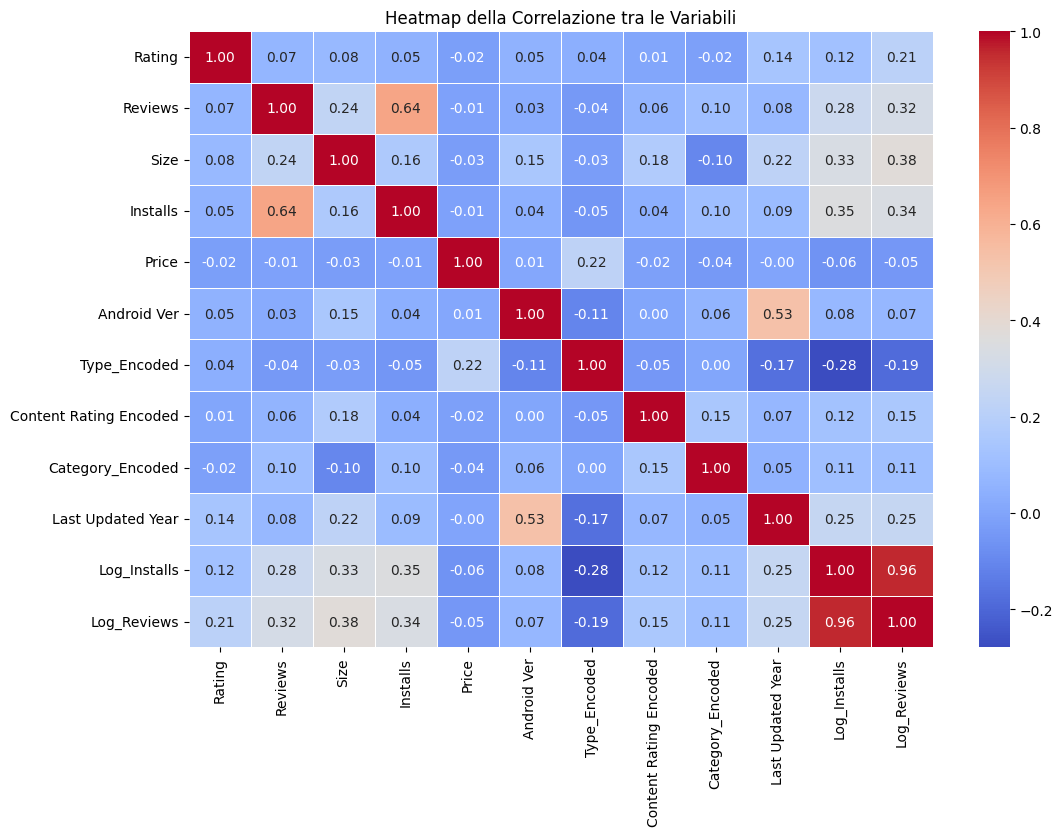

In [ ]:
app.head()

plt.figure(figsize=(12, 8))
sns.heatmap(app.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Heatmap della Correlazione tra le Variabili")
plt.show()

La correlazione tra i downloads e le relative recensioni sono rilevanti, eliminiamo quindi eventuali outliers calcolando lo z-score e rimuovendo le righe che hanno il valore assoluto di quest'ultimo maggiore di tre.
$$
z = \frac{x - \mu}{\sigma}
$$

In [ ]:
# Escludiamo le colonne che non ci interessano
app_for_outliers = app.drop(columns=['Size', 'Android Ver', 'Price', 'Type_Encoded']) 

# Assicuriamoci che tutte le colonne numeriche siano float64
numerical_columns = app_for_outliers.select_dtypes(include=[np.number]).columns
app_for_outliers[numerical_columns] = app_for_outliers[numerical_columns].astype('float64')

z_scores = pd.DataFrame(zscore(app_for_outliers[numerical_columns]), columns=numerical_columns)

# Resettiamo gli indici per garantire che siano allineati
app_reset = app_for_outliers.reset_index(drop=True)
z_scores_reset = z_scores.reset_index(drop=True)

# Rimuoviamo le righe con outliers
app_no_outliers = app_reset[(np.abs(z_scores_reset) <= 3).all(axis=1)]

print(app_no_outliers)

Visualizziando l'heatmap con i valori aggiornati possiamo notare che la correlazione tra i downloads e le recensioni è aumentata.

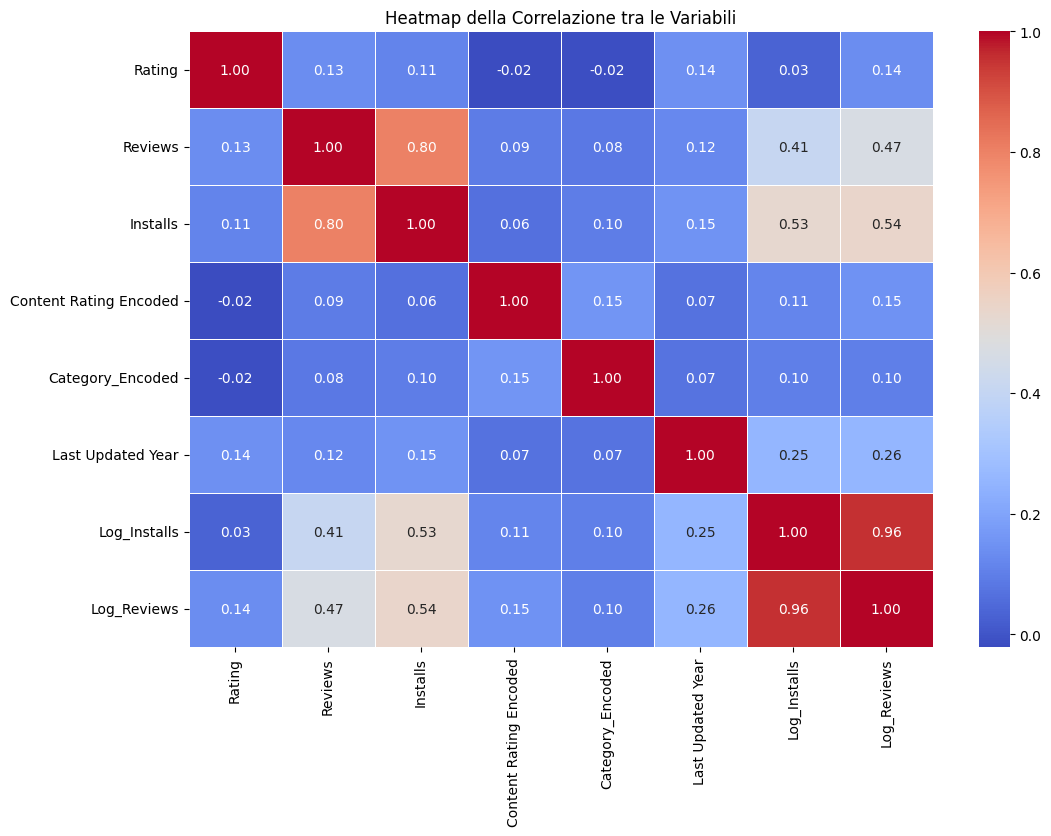

In [323]:
# Crea la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(app_no_outliers.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Mostra la heatmap
plt.title("Heatmap della Correlazione tra le Variabili")
plt.show()



Visualizziamo la correlazione graficamente tramite uno scatter plot.

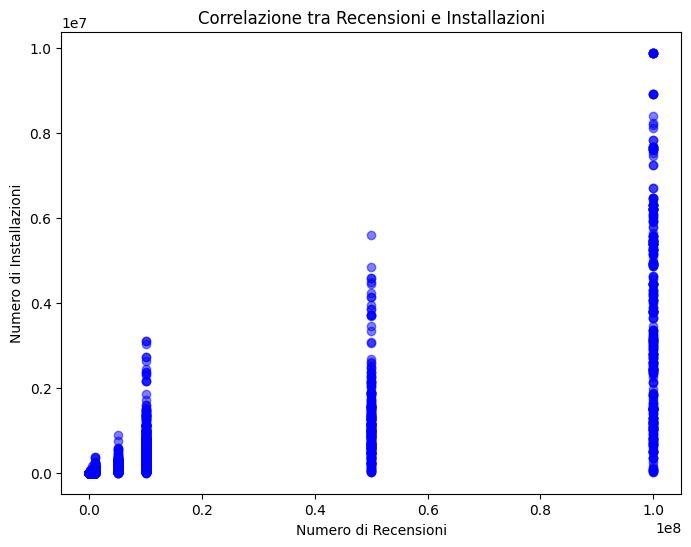

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(app_no_outliers['Installs'], app_no_outliers['Reviews'], alpha=0.5, color='blue')
plt.title('Correlazione tra Recensioni e Installazioni')
plt.xlabel('Numero di Recensioni')
plt.ylabel('Numero di Installazioni')
plt.show()

Siccome i dati sono distribuiti in modo sbilanciato(La maggior parte delle app può avere pochi download e recensioni, mentre alcune app possono avere numeri eccezionalmente alti), quindi applichiamo il logaritmo a tutte le variabili per ridurre la simmetria, ad esempio possiamo avere due app:

App A: 100 recensioni, 500 installazioni.
App B: 1.000.000 recensioni, 50.000.000 installazioni

La App A avrà un logaritmo di 2 (per esempio, log(100) ≈ 2).
La App B avrà un logaritmo di 6 (log(1.000.000) ≈ 6).

Quindi così facendo abbiamo ridotto il divario rendendo la correlazione più lineare.

Inoltre siccome qualsiasi logaritmo di 0 è indefinito sommiamo 1.

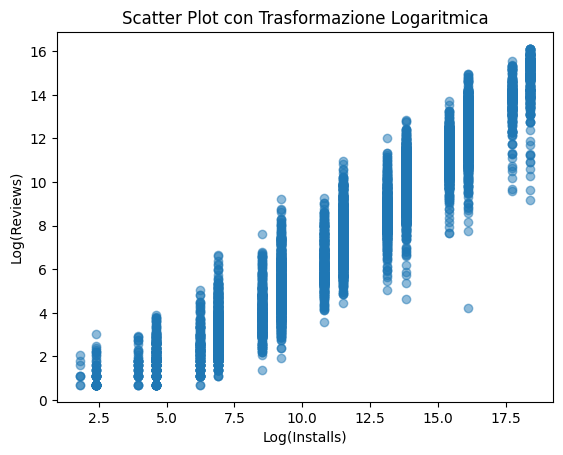

In [ ]:
# Trasformazione logaritmica
app_no_outliers['Log_Installs'] = np.log(app_no_outliers['Installs'] + 1)  # Aggiungiamo 1 per evitare log(0)
app_no_outliers['Log_Reviews'] = np.log(app_no_outliers['Reviews'] + 1)  # Aggiungiamo 1 per evitare log(0)

# Visualizza il grafico con i dati trasformati
plt.scatter(app_no_outliers['Log_Installs'], app_no_outliers['Log_Reviews'], alpha=0.5)
plt.xlabel("Log(Installs)")
plt.ylabel("Log(Reviews)")
plt.title("Scatter Plot con Trasformazione Logaritmica")
plt.show()

Calcoliamo e visualizziamo la retta di regressione lineare semplice per predire il numero di recensioni in base ai downloads. 
La **regressione lineare** utilizza il metodo dei **minimi quadrati** per trovare la retta che meglio si adatta ai dati. La formula della regressione lineare semplice è:

$$
y = \beta_0 + \beta_1 x
$$

- \( y \) è la variabile dipendente,
- \( x \) è la variabile indipendente,
- \( \beta_0 \) è l'intercetta,
- \( \beta_1 \) è il coefficiente angolare.

La **regressione lineare** utilizza il metodo dei **minimi quadrati** per trovare la retta che meglio si adatta ai dati.
Il metodo dei **minimi quadrati** cerca di minimizzare la somma dei quadrati delle differenze tra i valori osservati e i valori predetti.

$$
J(\beta_0, \beta_1) = \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2 = \sum_{i=1}^n \left( y_i - (\beta_0 + \beta_1 x_i) \right)^2
$$





Successivamente valutiamo il modello tramite l' **R² score** (coefficiente di determinazione).
L'**R² score** è una misura di quanto bene il modello spiega la variabilità dei dati. La formula per calcolare l'R² è:
$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
$$

Se \( R^2 = 1 \), il modello è perfetto. Se \( R^2 = 0 \), il modello non spiega nulla dei dati.


Coefficiente angolare (pendenza): 0.960660234951788
Intercetta: -3.4336240430887095


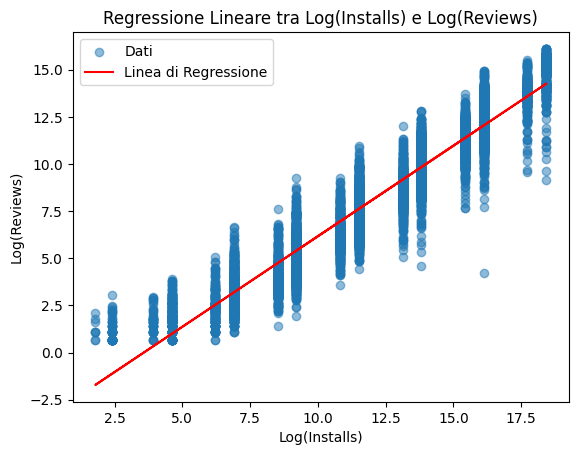

R²: 0.9138376714337597


In [ ]:
X = app_no_outliers[['Log_Installs']]
y = app_no_outliers['Log_Reviews']  

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Coefficiente angolare (pendenza): {slope}")
print(f"Intercetta: {intercept}")

# Visualizza il grafico di dispersione con la retta di regressione
plt.scatter(app_no_outliers['Log_Installs'], app_no_outliers['Log_Reviews'], alpha=0.5, label="Dati")
plt.plot(app_no_outliers['Log_Installs'], y_pred, color='red', label='Linea di Regressione')
plt.xlabel("Log(Installs)")
plt.ylabel("Log(Reviews)")
plt.title("Regressione Lineare tra Log(Installs) e Log(Reviews)")
plt.legend()
plt.show()

r2_score = model.score(X, y)
print(f"R²: {r2_score}")


Adesso alleniamo il modello comprendendo gli outlier nel dataset e calcoliamo la differenza assoluta tra le recensioni effettive e quelle previste dal modello. Questa differenza indica quanto un'app si discosta dalle nostre previsioni. Calcoliamo la media e la deviazione standard delle differenze tra i valori effettivi e i valori previsti e identifichiamo gli outliers: cioè le app per cui la differenza tra le recensioni effettive e quelle previste è superiore a 2 deviazioni standard dalla media. Queste app sono considerate sospette e le salviamo per visualizzarle in seguito in un altro dataset.

In [ ]:
# Rimuoviamo le colonne non numeriche per il calcolo
app_for_outliers = app.drop(columns=['Size', 'Android Ver', 'Price', 'Type_Encoded'], inplace=False)

app_for_outliers['Log_Installs'] = np.log(app_for_outliers['Installs'])
app_for_outliers['Log_Reviews'] = np.log(app_for_outliers['Reviews'])

X = app_for_outliers[['Log_Installs']] 
y = app_for_outliers['Log_Reviews']  

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

difference_outliers = np.abs(y - y_pred)

mean_diff_outliers = difference_outliers.mean()
std_diff_outliers = difference_outliers.std()

threshold_outliers = mean_diff_outliers + 2 * std_diff_outliers
suspicious_apps_outliers = app[difference_outliers > threshold_outliers]

# Aggiungiamo la colonna 'App' alle app sospette per ricaavarci il nome
suspicious_apps_outliers['App'] = app_names[suspicious_apps_outliers.index]

suspicious_apps_outliers['Log_Reviews'] = np.log(suspicious_apps_outliers['Reviews'])
suspicious_apps_outliers['Log_Installs'] = np.log(suspicious_apps_outliers['Installs'])

print(suspicious_apps_outliers[['App', 'Installs', 'Reviews', 'Log_Reviews', 'Log_Installs']])


                                                 App   Installs  Reviews  \
1                                Coloring book moana     500000      967   
27                             Animated Photo Editor     100000      203   
39     How To Color Disney Princess - Coloring Pages     500000      591   
41                      Sad Poetry Photo Frames 2018     100000      176   
47             Little Teddy Bear Colouring Book Game     100000       85   
...                                              ...        ...      ...   
10564                                 FK Dedinje BGD        100       36   
10647                              Motorola FM Radio  100000000    54815   
10659                                             FN         50       14   
10697                                        Mu.F.O.          1        2   
10809          Castle Clash: RPG War and Strategy FR    1000000   376223   

       Log_Reviews  Log_Installs  
1         6.874198     13.122363  
27        5.31320

In [329]:
suspicious_apps_outliers['App'].to_csv('suspicious_apps.csv', index=False)


Gli outliers in questo contesto sono app che presentano un comportamento significativamente diverso rispetto alla relazione che ci aspettiamo tra installazioni e recensioni. Come già menzionato, le app sospette potrebbero essere quelle che mostrano un numero di recensioni anomalo rispetto alle installazioni.

App con molte recensioni rispetto alle installazioni:
Se un'app ha un numero di recensioni elevato ma poche installazioni, ciò potrebbe indicare che le recensioni sono acquistate o manipolate in qualche modo. Queste pratiche sono comuni in app che cercano di aumentare artificialmente la propria visibilità o reputazione. Le recensioni fittizie potrebbero provenire da bot, da utenti incentivati, o da recensioni false create da agenzie di marketing. In questi casi, anche se il numero di recensioni è alto, la bassa base di installazioni potrebbe far emergere una discrepanza significativa rispetto alla relazione naturale tra queste due variabili.

Un altro scenario potrebbe essere che un'app abbia molte recensioni in breve tempo, il che potrebbe essere il risultato di campagne promozionali aggressive o strategie di marketing che incentivano gli utenti a lasciare recensioni. Queste recensioni, se non sono autentiche, potrebbero non riflettere un vero interesse o engagement per l'app, ma piuttosto essere il risultato di incentivi esterni.

App con molte installazioni ma poche recensioni:
D'altro canto, se un'app ha installazioni elevate, ma poche recensioni, questo potrebbe suggerire una mancanza di engagement da parte degli utenti. Sebbene l'app possa essere stata scaricata da molti utenti, questi utenti potrebbero non interagire con l'app o non sentirsi motivati a lasciare recensioni. Questo potrebbe essere un segno di un'app che, pur avendo una buona visibilità e un alto numero di download, non sta generando un coinvolgimento reale o soddisfazione da parte degli utenti. Ciò potrebbe essere dovuto a problemi di usabilità, esperienza utente scarsa, o funzionalità limitate che non soddisfano le aspettative degli utenti.
Altri possibili problemi
Oltre alle manipolazioni delle recensioni e alla mancanza di engagement, ci potrebbero essere altre spiegazioni che giustificano la presenza di outliers:

Marketing aggressivo vs crescita naturale:
Alcune app potrebbero aver adottato strategie di marketing virale o campagne pubblicitarie aggressive che portano a un forte aumento delle installazioni senza necessariamente tradursi in un numero proporzionato di recensioni. Questo potrebbe essere il caso di app che puntano molto sulla visibilità attraverso la pubblicità, ma che non riescono a fidelizzare i propri utenti a lungo termine.
Al contrario, alcune app potrebbero non aver investito in marketing, ma hanno ricevuto un grande numero di installazioni organiche da parte degli utenti che sono rimasti soddisfatti e hanno lasciato recensioni in modo genuino. Tuttavia, anche se la relazione tra installazioni e recensioni sembra naturale, la qualità del prodotto potrebbe non essere all'altezza, e le recensioni potrebbero non essere rappresentative di un'app ben progettata.

Differenti modelli di business:

Alcune app, come quelle di utilità o strumenti di sistema, potrebbero essere scaricate frequentemente ma non richiedere molte recensioni o interazioni da parte degli utenti, portando a una discrepanza tra il numero di installazioni e recensioni. In questi casi, gli utenti potrebbero scaricare l'app per un singolo scopo, senza però sentirsi motivati a lasciare un feedback.
Al contrario, app come i giochi o le app di social media tendono ad avere una maggiore interazione da parte degli utenti, che sono più inclini a lasciare recensioni o feedback.

In sintesi le app con recensioni negative o scarse rispetto al numero di installazioni potrebbero avere problemi di qualità o esperienza utente. Un'app che ottiene molte installazioni iniziali ma ha recensioni scadenti potrebbe suggerire che, pur essendo stata scaricata da molti utenti, non è riuscita a mantenere un alto livello di soddisfazione tra gli utenti. Potrebbe esserci un bug persistente, un'interfaccia utente poco intuitiva, o funzionalità non implementate correttamente.